In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from statsmodels.tsa.arima.model import ARIMA

import warnings
warnings.filterwarnings("ignore")

In [3]:

df = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")

print(df.head())

print(df.info())

   Year  Month         Region    Model  Estimated_Deliveries  \
0  2023      5         Europe  Model S                 17646   
1  2015      2           Asia  Model X                  3797   
2  2019      1  North America  Model X                  8411   
3  2021      2  North America  Model 3                  6555   
4  2016     12    Middle East  Model Y                 12374   

   Production_Units  Avg_Price_USD  Battery_Capacity_kWh  Range_km  \
0             17922       92874.27                   120       704   
1              4164       62205.65                    75       438   
2              9189      117887.32                    82       480   
3              7311       89294.91                   120       712   
4             13537      114846.78                   120       661   

   CO2_Saved_tons           Source_Type  Charging_Stations  
0         1863.42  Interpolated (Month)              12207  
1          249.46    Official (Quarter)               7640  
2          

In [5]:
print(df.isnull().sum())

df.drop_duplicates(inplace=True)

print("Shape:", df.shape)

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64
Shape: (2640, 12)


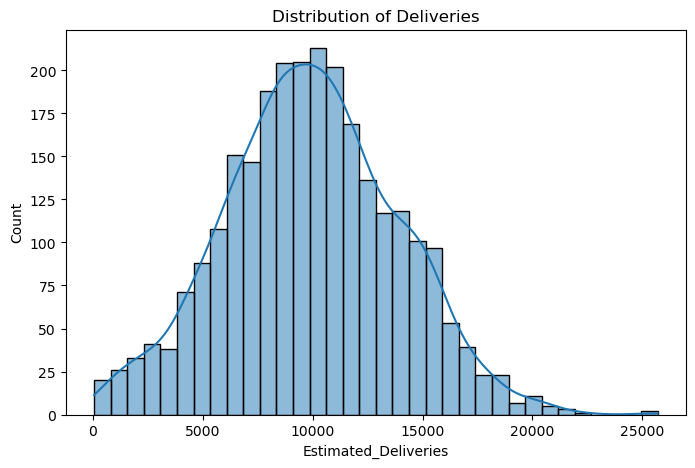

In [7]:
plt.figure(figsize=(8,5))
sns.histplot(df["Estimated_Deliveries"], kde=True)
plt.title("Distribution of Deliveries")
plt.show()


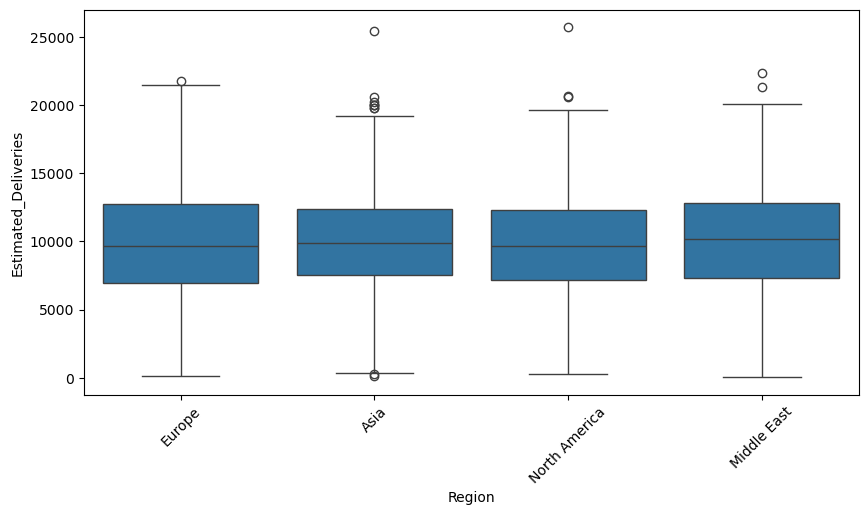

In [9]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x="Region",
    y="Estimated_Deliveries",
    data=df
)

plt.xticks(rotation=45)

plt.show()

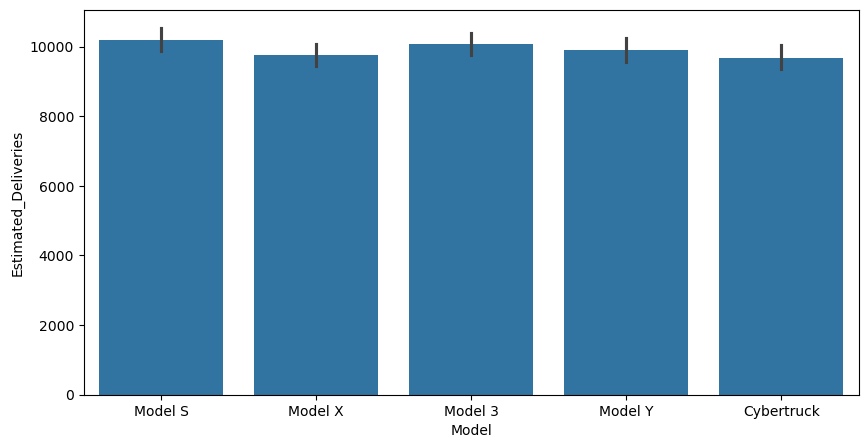

In [11]:
plt.figure(figsize=(10,5))

sns.barplot(
    x="Model",
    y="Estimated_Deliveries",
    data=df
)

plt.show()

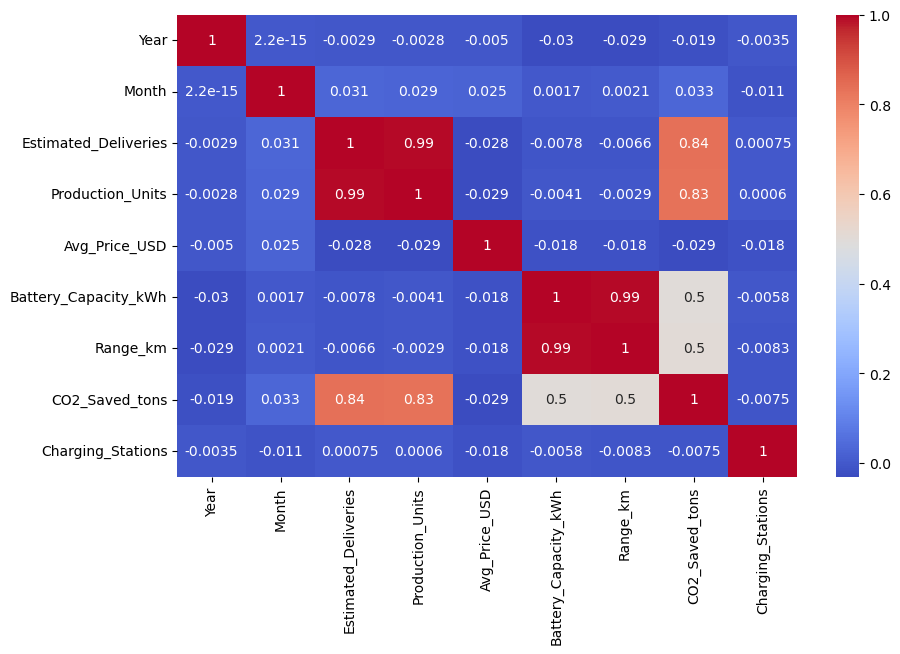

In [13]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

In [15]:
df["Price_per_km"] = (
    df["Avg_Price_USD"] /
    df["Range_km"]
)

df["Delivery_Production_Ratio"] = (
    df["Estimated_Deliveries"] /
    df["Production_Units"]
)

df["Year_Month"] = (
    df["Year"]*100 +
    df["Month"]
)

In [17]:
X = df.drop(
    "Estimated_Deliveries",
    axis=1
)

y = df["Estimated_Deliveries"]

In [31]:
categorical_features = [
    "Region",
    "Model",
    "Source_Type"
]

numerical_features = [
    "Year",
    "Month",
    "Production_Units",
    "Avg_Price_USD",
    "Battery_Capacity_kWh",
    "Range_km",
    "CO2_Saved_tons",
    "Charging_Stations",
    "Price_per_km",
    "Delivery_Production_Ratio",
    "Year_Month"
]

print(categorical_features)
print(numerical_features)

['Region', 'Model', 'Source_Type']
['Year', 'Month', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Charging_Stations', 'Price_per_km', 'Delivery_Production_Ratio', 'Year_Month']


In [33]:
numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        )
    ]
)

In [35]:
categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),

        (
            "onehot",
            OneHotEncoder(handle_unknown="ignore")
        )
    ]
)

In [37]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numerical_features
        ),

        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(2112, 14)
(528, 14)


In [41]:
pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),

        (
            "model",
            RandomForestRegressor(
                random_state=42
            )
        )
    ]
)

In [43]:
param_grid = {
    "model__n_estimators":[100,200],

    "model__max_depth":[
        5,
        10,
        20
    ],

    "model__min_samples_split":[
        2,
        5
    ]
}

In [45]:
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    error_score="raise"
)

grid_search.fit(
    X_train,
    y_train
)

print(
    "Best Parameters:",
    grid_search.best_params_
)

Best Parameters: {'model__max_depth': 20, 'model__min_samples_split': 2, 'model__n_estimators': 200}


In [47]:
best_model = grid_search.best_estimator_

In [49]:
predictions = best_model.predict(
    X_test
)

In [51]:
mae = mean_absolute_error(
    y_test,
    predictions
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        predictions
    )
)

r2 = r2_score(
    y_test,
    predictions
)

print("MAE :", mae)

print("RMSE :", rmse)

print("R2 Score :", r2)

MAE : 67.23621212121209
RMSE : 112.10395055702732
R2 Score : 0.9991569131350697


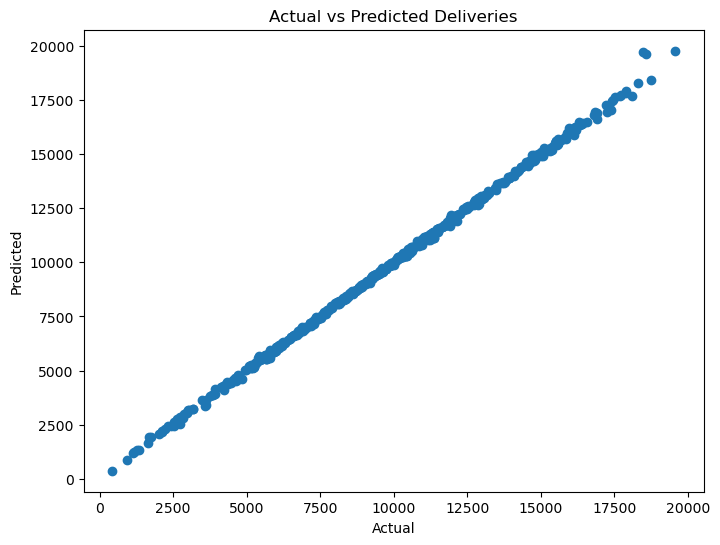

In [53]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    predictions
)

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.title(
    "Actual vs Predicted Deliveries"
)

plt.show()

In [55]:
model = best_model.named_steps["model"]

feature_names = (
    best_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

importance = model.feature_importances_

importance_df = pd.DataFrame({
    "Feature":feature_names,
    "Importance":importance
})

importance_df = (
    importance_df
    .sort_values(
        by="Importance",
        ascending=False
    )
)

importance_df.head(15)

,Feature,Importance
2,num__Production_Units,0.990207
9,num__Delivery_Production_Ratio,0.008649
6,num__CO2_Saved_tons,0.000210
10,num__Year_Month,0.000197
8,num__Price_per_km,0.000135
3,num__Avg_Price_USD,0.000097
7,num__Charging_Stations,0.000093
1,num__Month,0.000086
5,num__Range_km,0.000062
0,num__Year,0.000058


In [57]:
model = best_model.named_steps["model"]

feature_names = (
    best_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

importance = model.feature_importances_

importance_df = pd.DataFrame({
    "Feature":feature_names,
    "Importance":importance
})

importance_df = (
    importance_df
    .sort_values(
        by="Importance",
        ascending=False
    )
)

importance_df.head(15)

,Feature,Importance
2,num__Production_Units,0.990207
9,num__Delivery_Production_Ratio,0.008649
6,num__CO2_Saved_tons,0.000210
10,num__Year_Month,0.000197
8,num__Price_per_km,0.000135
3,num__Avg_Price_USD,0.000097
7,num__Charging_Stations,0.000093
1,num__Month,0.000086
5,num__Range_km,0.000062
0,num__Year,0.000058


In [59]:
import joblib

joblib.dump(
    best_model,
    "tesla_delivery_model.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully
